In [22]:
from exact_QAOA_probs import exact_probs
from kraus_samples_simulation import kraus_samples_probs
from monte_carlo_simulation import monte_carlo_probs
import numpy as np
import matplotlib.pyplot as plt

# Зависимость от числа симуляций

Параметры симуляции

In [23]:
num_qubits = 6
sigma_1q = 1
sigma_2q = 1

seed = 42

In [24]:
def dist(p_th, p_exp, sig_exp):
    # Фиделити считается сразу по всем элементам тензора
    dist_sum = np.sum((p_th - p_exp)**2)
    mask = p_exp > 0
    
    err = np.sum(4*(p_th[mask] - p_exp[mask])**2 * (sig_exp[mask] ** 2))
    
    return dist_sum, np.sqrt(err)

In [27]:
# Варьируем число симуляций
K = np.arange(10, 1510, 10)

dist_kraus_exact = []
dist_monte_carlo_exact = []

dist_kraus_exact_err = []
dist_monte_carlo_exact_err = []

p = 1 # все для 1 слоя

exact = exact_probs(num_qubits=num_qubits, p = p, 
                        sigma_1q=sigma_1q, sigma_2q=sigma_2q, seed=seed)

for num_of_simulations in K:
    temp_kraus_exact = []
    temp_monte_carlo_exact = []

    kraus_probs, kraus_err = kraus_samples_probs(num_qubits=num_qubits, p = p, num_samples=num_of_simulations, 
                                    sigma_1q=sigma_1q, sigma_2q=sigma_2q, seed=seed)
    monte_probs, monte_err = monte_carlo_probs(num_qubits=num_qubits, p = p, num_samples=num_of_simulations, 
                                    sigma_1q=sigma_1q, sigma_2q=sigma_2q, seed=seed)
    
    dist_kr_res = dist(exact, kraus_probs, kraus_err)
    dist_mc_res = dist(exact, monte_probs, monte_err)

    dist_kraus_exact.append(dist_kr_res[0])
    dist_monte_carlo_exact.append(dist_mc_res[0])
    dist_kraus_exact_err.append(dist_kr_res[1])
    dist_monte_carlo_exact_err.append(dist_mc_res[1])

dist_kraus_exact = np.array(dist_kraus_exact)
dist_monte_carlo_exact = np.array(dist_monte_carlo_exact)
dist_kraus_exact_err = np.array(dist_kraus_exact_err)
dist_monte_carlo_exact_err = np.array(dist_monte_carlo_exact_err)

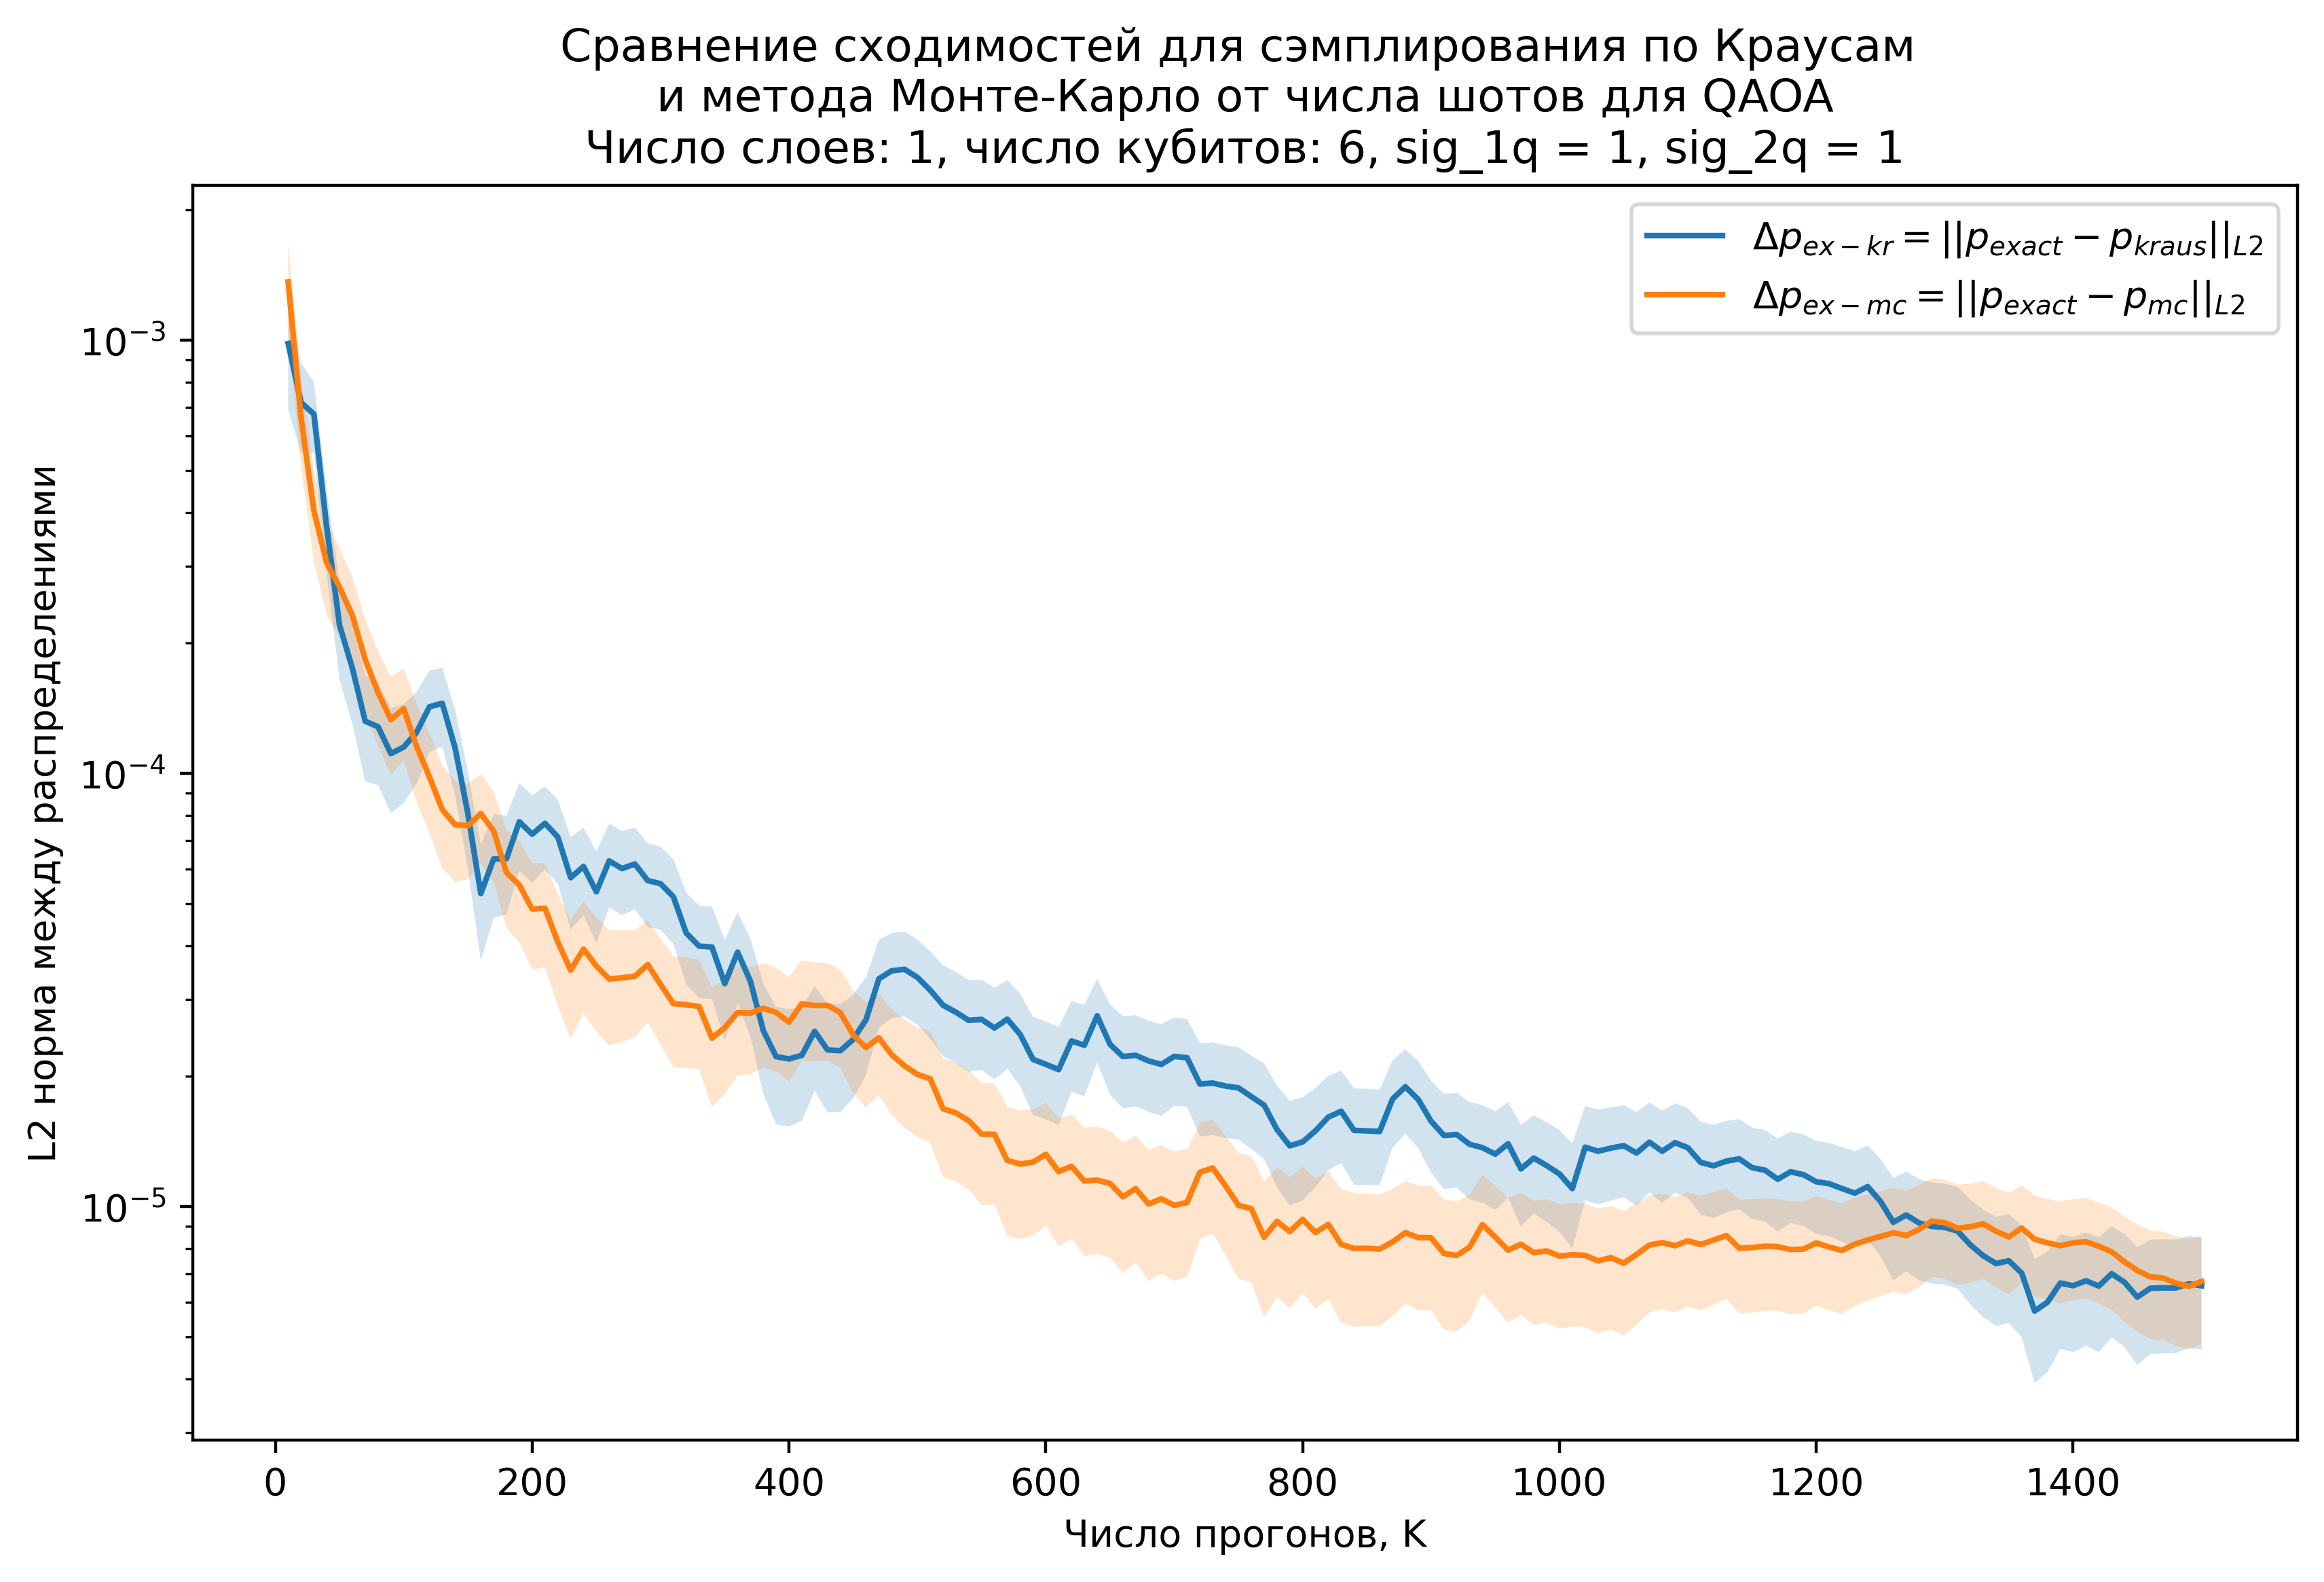

In [28]:
plt.figure(figsize=(10, 6), dpi=400)
plt.plot(K, dist_kraus_exact, label=r'$\Delta p_{ex-kr} = ||p_{exact} - p_{kraus}||_{L2}$')# marker='o', markerfacecolor='none')
plt.plot(K, dist_monte_carlo_exact, label=r'$\Delta p_{ex-mc} = ||p_{exact} - p_{mc}||_{L2}$')#, marker='v', markerfacecolor='none')

plt.fill_between(K, dist_kraus_exact - dist_kraus_exact_err, dist_kraus_exact + dist_kraus_exact_err, alpha=0.2)
plt.fill_between(K, dist_monte_carlo_exact - dist_monte_carlo_exact_err, dist_monte_carlo_exact + dist_monte_carlo_exact_err, alpha=0.2)

plt.xlabel('Число прогонов, K')
plt.ylabel(r'L2 норма между распределениями')
plt.yscale('log') # Теперь, если вы раскомментируете логарифмический масштаб, график не выдаст ошибку
plt.legend()
plt.title(f'Сравнение сходимостей для сэмплирования по Краусам \nи метода Монте-Карло от числа шотов для QAOA\nЧисло слоев: {p}, число кубитов: {num_qubits}, sig_1q = {sigma_1q}, sig_2q = {sigma_2q}')
plt.show()

# Зависимость от числа слоев

In [29]:
# Варьируем число симуляций
layers = np.arange(1, 10, 1)

dist_kraus_exact = []
dist_monte_carlo_exact = []

dist_kraus_exact_err = []
dist_monte_carlo_exact_err = []

K = 100 # число шотов на каждой итерации

for p in layers:
    exact = exact_probs(num_qubits=num_qubits, p = p, 
                        sigma_1q=sigma_1q, sigma_2q=sigma_2q, seed=seed)
    
    temp_kraus_exact = []
    temp_monte_carlo_exact = []

    kraus_probs, kraus_err = kraus_samples_probs(num_qubits=num_qubits, p = p, num_samples=K, 
                                    sigma_1q=sigma_1q, sigma_2q=sigma_2q, seed=seed)
    monte_probs, monte_err = monte_carlo_probs(num_qubits=num_qubits, p = p, num_samples=K, 
                                    sigma_1q=sigma_1q, sigma_2q=sigma_2q, seed=seed)
    
    dist_kr_res = dist(exact, kraus_probs, kraus_err)
    dist_mc_res = dist(exact, monte_probs, monte_err)

    dist_kraus_exact.append(dist_kr_res[0])
    dist_monte_carlo_exact.append(dist_mc_res[0])
    dist_kraus_exact_err.append(dist_kr_res[1])
    dist_monte_carlo_exact_err.append(dist_mc_res[1])

dist_kraus_exact = np.array(dist_kraus_exact)
dist_monte_carlo_exact = np.array(dist_monte_carlo_exact)
dist_kraus_exact_err = np.array(dist_kraus_exact_err)
dist_monte_carlo_exact_err = np.array(dist_monte_carlo_exact_err)

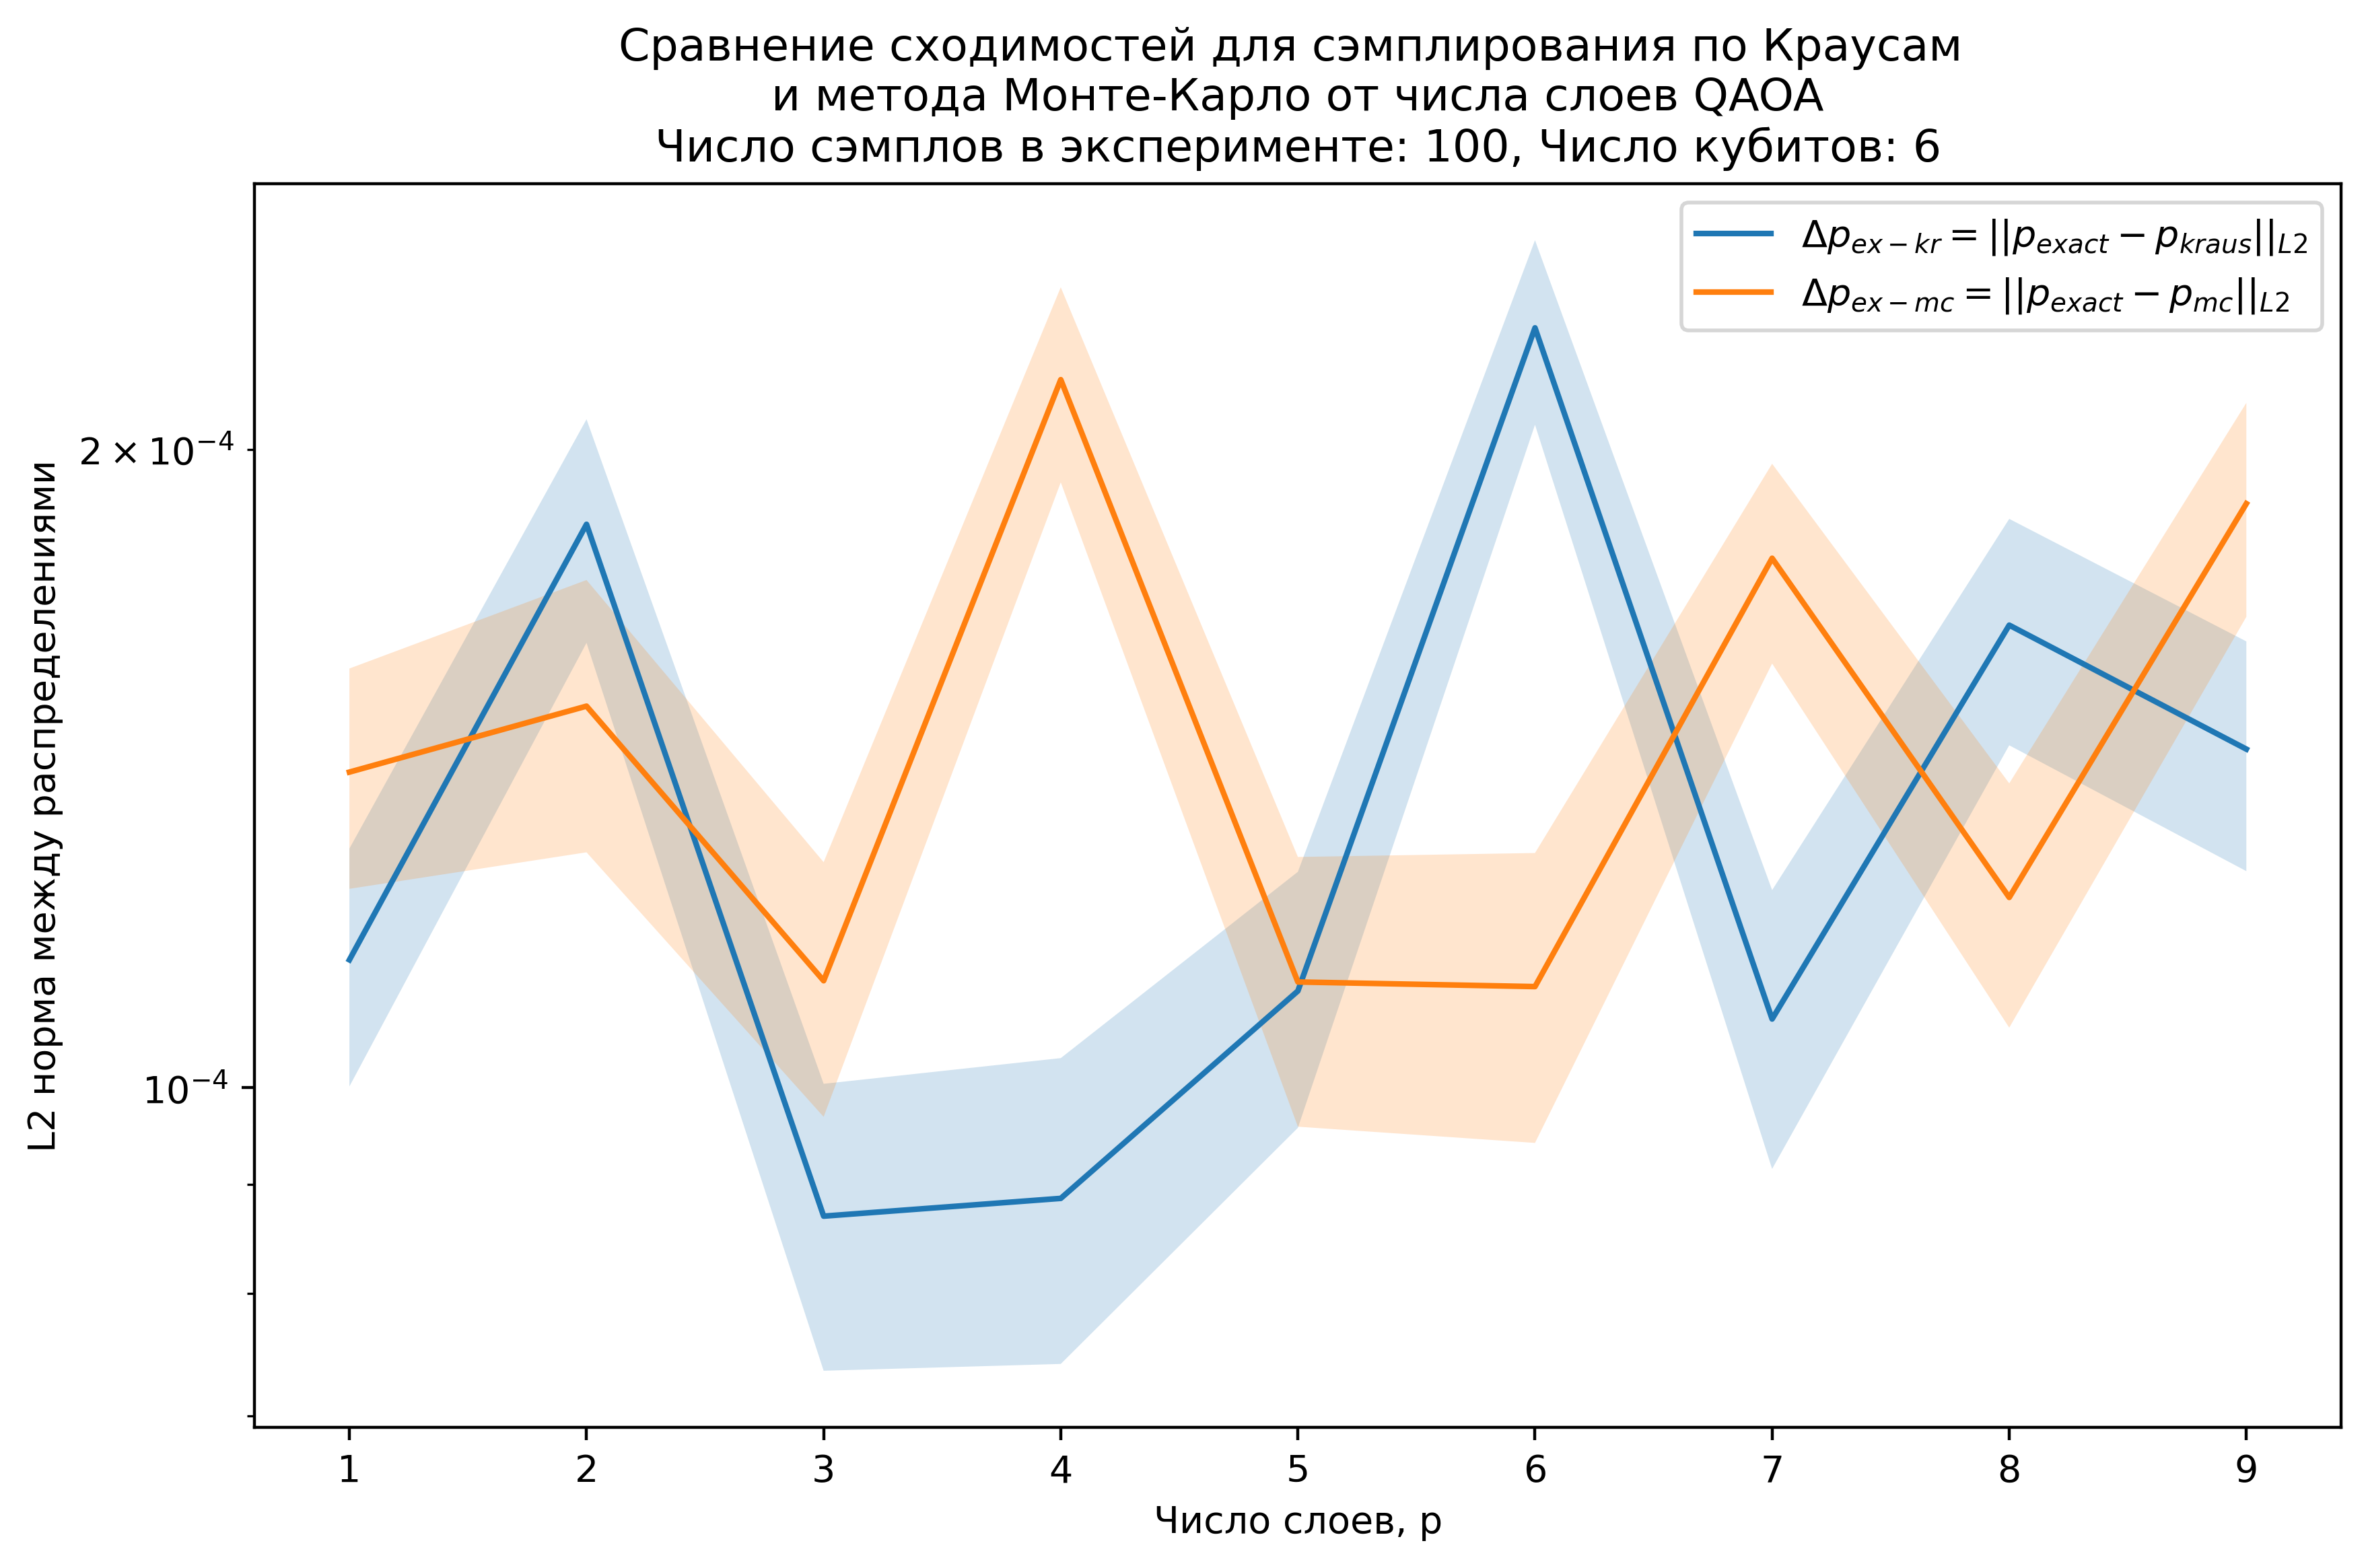

In [30]:
plt.figure(figsize=(10, 6), dpi=400)
plt.plot(layers, dist_kraus_exact, label=r'$\Delta p_{ex-kr} = ||p_{exact} - p_{kraus}||_{L2}$')# marker='o', markerfacecolor='none')
plt.plot(layers, dist_monte_carlo_exact, label=r'$\Delta p_{ex-mc} = ||p_{exact} - p_{mc}||_{L2}$')#, marker='v', markerfacecolor='none')

plt.fill_between(layers, dist_kraus_exact - dist_kraus_exact_err/2, dist_kraus_exact + dist_kraus_exact_err/2, alpha=0.2)
plt.fill_between(layers, dist_monte_carlo_exact - 0.5 * dist_monte_carlo_exact_err, dist_monte_carlo_exact + 0.5 * dist_monte_carlo_exact_err, alpha=0.2)

plt.xlabel('Число слоев, p')
plt.ylabel(r'L2 норма между распределениями')
plt.yscale('log') # Теперь, если вы раскомментируете логарифмический масштаб, график не выдаст ошибку
plt.legend()
plt.title(f'Сравнение сходимостей для сэмплирования по Краусам \nи метода Монте-Карло от числа слоев QAOA\nЧисло сэмплов в эксперименте: {K}, Число кубитов: {num_qubits}')
plt.show()

# Другие sigma

In [31]:
sigma_1q = 0.1
sigma_2q = 0.2

In [33]:
# Варьируем число симуляций
K = np.arange(10, 1510, 10)

dist_kraus_exact = []
dist_monte_carlo_exact = []

dist_kraus_exact_err = []
dist_monte_carlo_exact_err = []

p = 1 # все для 1 слоя

exact = exact_probs(num_qubits=num_qubits, p = p, 
                        sigma_1q=sigma_1q, sigma_2q=sigma_2q, seed=seed)

for num_of_simulations in K:
    temp_kraus_exact = []
    temp_monte_carlo_exact = []

    kraus_probs, kraus_err = kraus_samples_probs(num_qubits=num_qubits, p = p, num_samples=num_of_simulations, 
                                    sigma_1q=sigma_1q, sigma_2q=sigma_2q, seed=seed)
    monte_probs, monte_err = monte_carlo_probs(num_qubits=num_qubits, p = p, num_samples=num_of_simulations, 
                                    sigma_1q=sigma_1q, sigma_2q=sigma_2q, seed=seed)
    
    dist_kr_res = dist(exact, kraus_probs, kraus_err)
    dist_mc_res = dist(exact, monte_probs, monte_err)

    dist_kraus_exact.append(dist_kr_res[0])
    dist_monte_carlo_exact.append(dist_mc_res[0])
    dist_kraus_exact_err.append(dist_kr_res[1])
    dist_monte_carlo_exact_err.append(dist_mc_res[1])

dist_kraus_exact = np.array(dist_kraus_exact)
dist_monte_carlo_exact = np.array(dist_monte_carlo_exact)
dist_kraus_exact_err = np.array(dist_kraus_exact_err)
dist_monte_carlo_exact_err = np.array(dist_monte_carlo_exact_err)

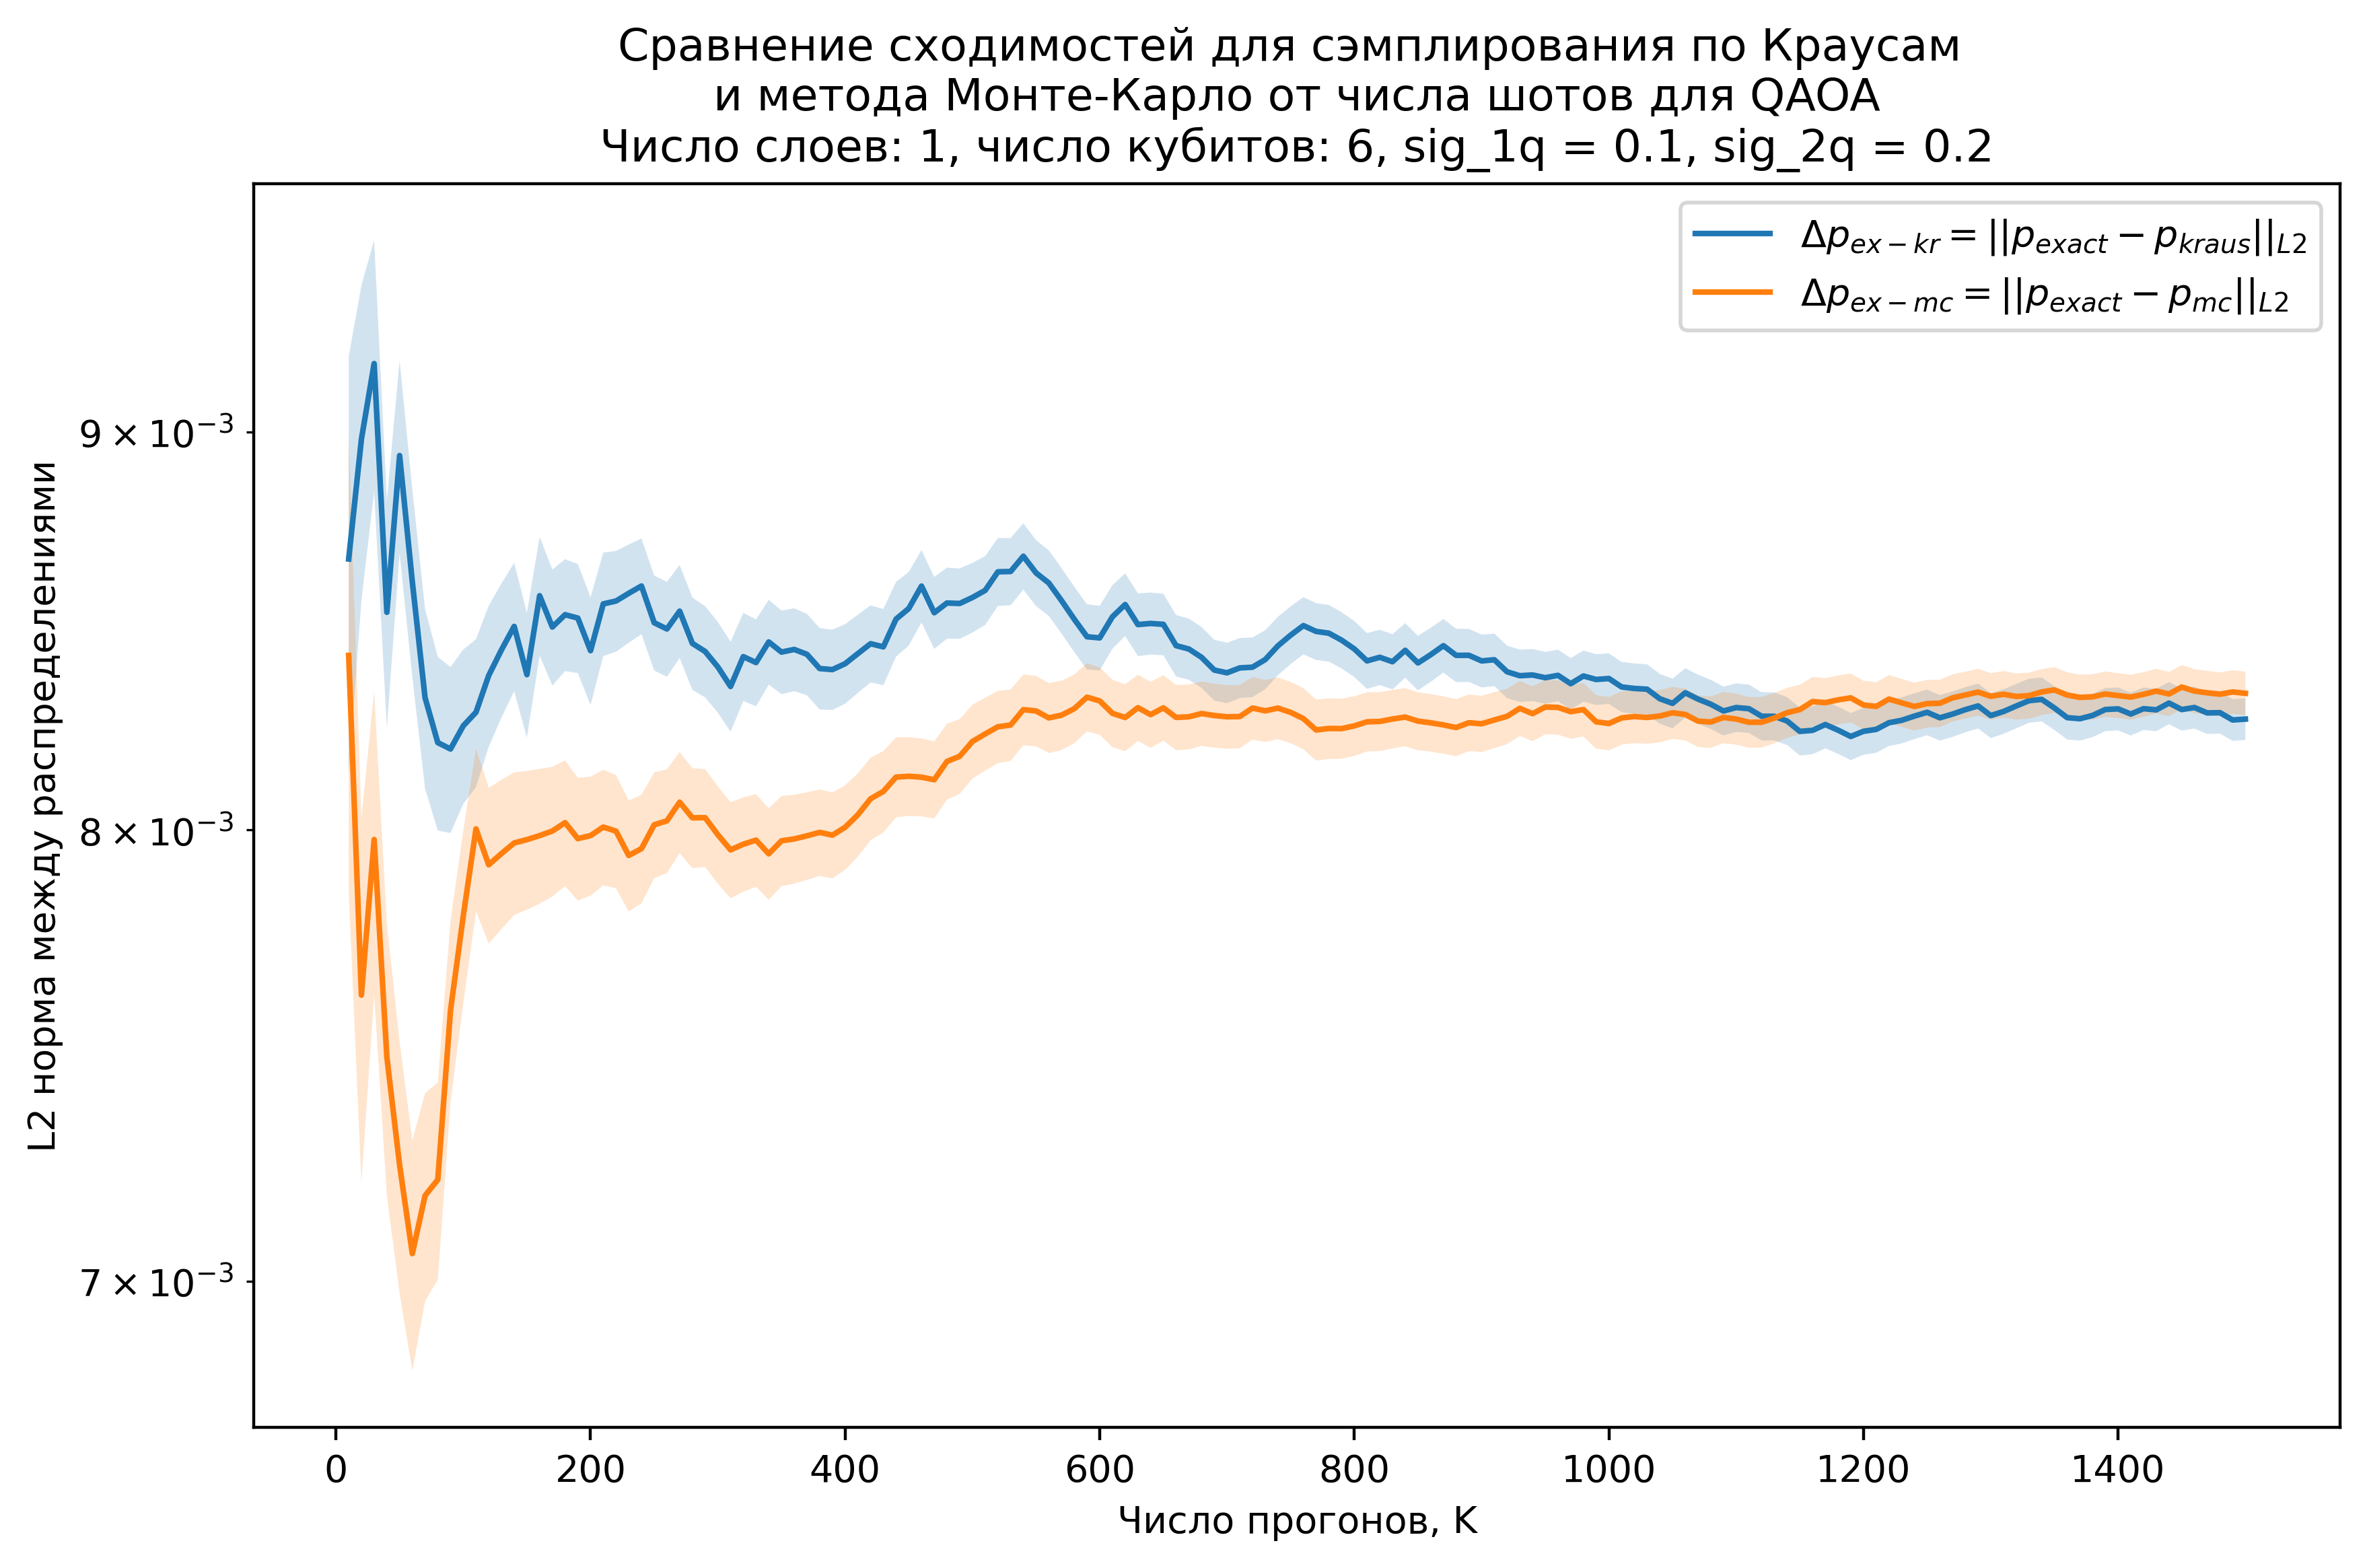

In [34]:
plt.figure(figsize=(10, 6), dpi=400)
plt.plot(K, dist_kraus_exact, label=r'$\Delta p_{ex-kr} = ||p_{exact} - p_{kraus}||_{L2}$')# marker='o', markerfacecolor='none')
plt.plot(K, dist_monte_carlo_exact, label=r'$\Delta p_{ex-mc} = ||p_{exact} - p_{mc}||_{L2}$')#, marker='v', markerfacecolor='none')

plt.fill_between(K, dist_kraus_exact - dist_kraus_exact_err, dist_kraus_exact + dist_kraus_exact_err, alpha=0.2)
plt.fill_between(K, dist_monte_carlo_exact - dist_monte_carlo_exact_err, dist_monte_carlo_exact + dist_monte_carlo_exact_err, alpha=0.2)

plt.xlabel('Число прогонов, K')
plt.ylabel(r'L2 норма между распределениями')
plt.yscale('log') # Теперь, если вы раскомментируете логарифмический масштаб, график не выдаст ошибку
plt.legend()
plt.title(f'Сравнение сходимостей для сэмплирования по Краусам \nи метода Монте-Карло от числа шотов для QAOA\nЧисло слоев: {p}, число кубитов: {num_qubits}, sig_1q = {sigma_1q}, sig_2q = {sigma_2q}')
plt.show()

In [35]:
sigma_1q = 0.01
sigma_2q = 1

In [36]:
# Варьируем число симуляций
K = np.arange(10, 1510, 10)

dist_kraus_exact = []
dist_monte_carlo_exact = []

dist_kraus_exact_err = []
dist_monte_carlo_exact_err = []

p = 1 # все для 1 слоя

exact = exact_probs(num_qubits=num_qubits, p = p, 
                        sigma_1q=sigma_1q, sigma_2q=sigma_2q, seed=seed)

for num_of_simulations in K:
    temp_kraus_exact = []
    temp_monte_carlo_exact = []

    kraus_probs, kraus_err = kraus_samples_probs(num_qubits=num_qubits, p = p, num_samples=num_of_simulations, 
                                    sigma_1q=sigma_1q, sigma_2q=sigma_2q, seed=seed)
    monte_probs, monte_err = monte_carlo_probs(num_qubits=num_qubits, p = p, num_samples=num_of_simulations, 
                                    sigma_1q=sigma_1q, sigma_2q=sigma_2q, seed=seed)
    
    dist_kr_res = dist(exact, kraus_probs, kraus_err)
    dist_mc_res = dist(exact, monte_probs, monte_err)

    dist_kraus_exact.append(dist_kr_res[0])
    dist_monte_carlo_exact.append(dist_mc_res[0])
    dist_kraus_exact_err.append(dist_kr_res[1])
    dist_monte_carlo_exact_err.append(dist_mc_res[1])

dist_kraus_exact = np.array(dist_kraus_exact)
dist_monte_carlo_exact = np.array(dist_monte_carlo_exact)
dist_kraus_exact_err = np.array(dist_kraus_exact_err)
dist_monte_carlo_exact_err = np.array(dist_monte_carlo_exact_err)

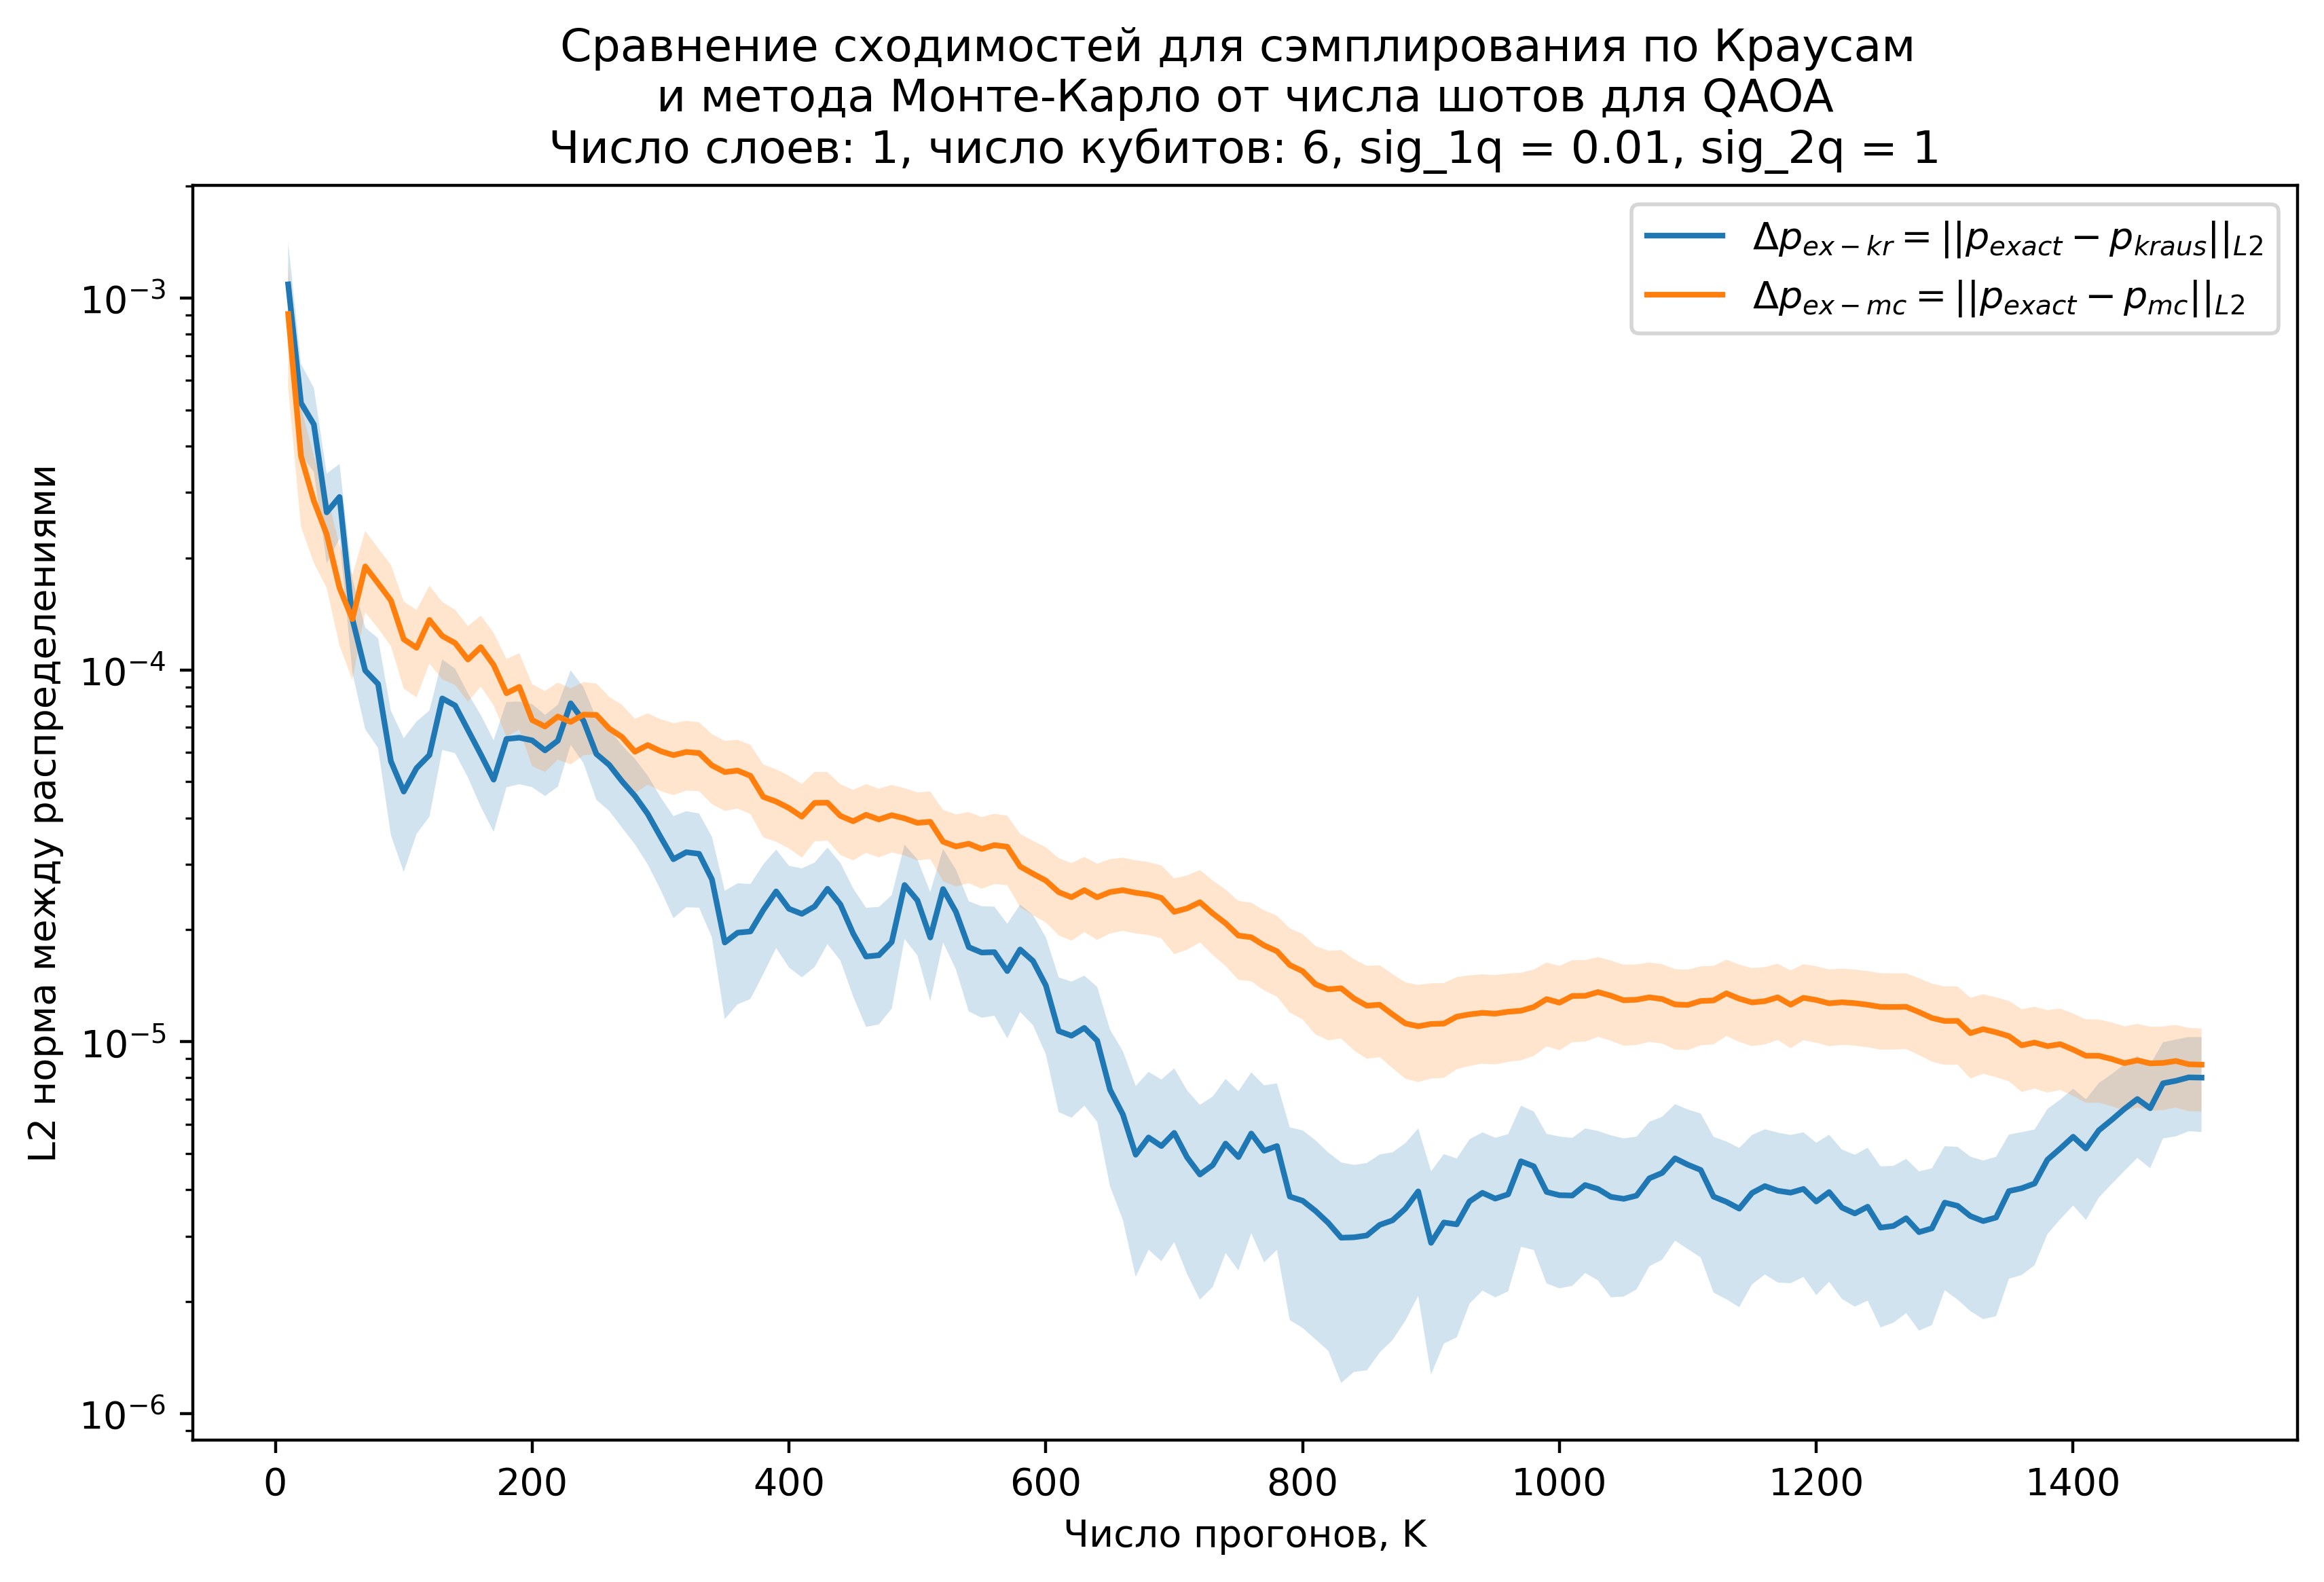

In [37]:
plt.figure(figsize=(10, 6), dpi=400)
plt.plot(K, dist_kraus_exact, label=r'$\Delta p_{ex-kr} = ||p_{exact} - p_{kraus}||_{L2}$')# marker='o', markerfacecolor='none')
plt.plot(K, dist_monte_carlo_exact, label=r'$\Delta p_{ex-mc} = ||p_{exact} - p_{mc}||_{L2}$')#, marker='v', markerfacecolor='none')

plt.fill_between(K, dist_kraus_exact - dist_kraus_exact_err, dist_kraus_exact + dist_kraus_exact_err, alpha=0.2)
plt.fill_between(K, dist_monte_carlo_exact - dist_monte_carlo_exact_err, dist_monte_carlo_exact + dist_monte_carlo_exact_err, alpha=0.2)

plt.xlabel('Число прогонов, K')
plt.ylabel(r'L2 норма между распределениями')
plt.yscale('log') # Теперь, если вы раскомментируете логарифмический масштаб, график не выдаст ошибку
plt.legend()
plt.title(f'Сравнение сходимостей для сэмплирования по Краусам \nи метода Монте-Карло от числа шотов для QAOA\nЧисло слоев: {p}, число кубитов: {num_qubits}, sig_1q = {sigma_1q}, sig_2q = {sigma_2q}')
plt.show()

# Зависимость от шума для разных графиков

In [38]:
sigmas_1q = np.arange(0.01, 1.01, 0.2)
sigma_2q = 1

In [ ]:
K = np.arange(10, 1010, 10)

# Словари для накопления данных
results_kraus = {}
results_mc = {}
errors_kraus = {}
errors_mc = {}

# Запуск симуляций
for sig_1q in sigmas_1q:
    dist_kraus_exact = []
    dist_monte_carlo_exact = []
    dist_kraus_exact_err = []
    dist_monte_carlo_exact_err = []

    # Точное распределение для текущих параметров шума
    exact = exact_probs(num_qubits=num_qubits, p=p, 
                        sigma_1q=sig_1q, sigma_2q=sigma_2q, seed=seed)
    
    for num_of_simulations in K:
        kraus_probs, kraus_err = kraus_samples_probs(
            num_qubits=num_qubits, p=p, num_samples=num_of_simulations, 
            sigma_1q=sig_1q, sigma_2q=sigma_2q, seed=seed
        )
        monte_probs, monte_err = monte_carlo_probs(
            num_qubits=num_qubits, p=p, num_samples=num_of_simulations, 
            sigma_1q=sig_1q, sigma_2q=sigma_2q, seed=seed
        )
        
        # Расчет расстояний (предполагается, что dist возвращает L2 норму и ошибку)
        dist_kr_res = dist(exact, kraus_probs, kraus_err)
        dist_mc_res = dist(exact, monte_probs, monte_err)

        dist_kraus_exact.append(dist_kr_res[0])
        dist_monte_carlo_exact.append(dist_mc_res[0])
        dist_kraus_exact_err.append(dist_kr_res[1])
        dist_monte_carlo_exact_err.append(dist_mc_res[1])

    # Сохраняем в словари как numpy массивы
    results_kraus[sig_1q] = np.array(dist_kraus_exact)
    results_mc[sig_1q] = np.array(dist_monte_carlo_exact)
    errors_kraus[sig_1q] = np.array(dist_kraus_exact_err)
    errors_mc[sig_1q] = np.array(dist_monte_carlo_exact_err)

<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\s'
/var/folders/86/5xcctjn15052xcf5hwdbv_6h0000gp/T/ipykernel_39343/4101184756.py:34: SyntaxWarning: invalid escape sequence '\s'
  plt.suptitle(f'Сходимость QAOA для разных уровней однокубитного шума\n(Слоев: {p}, Кубитов: {num_qubits}, $\sigma_{{2q}}$: {sigma_2q})', fontsize=18)


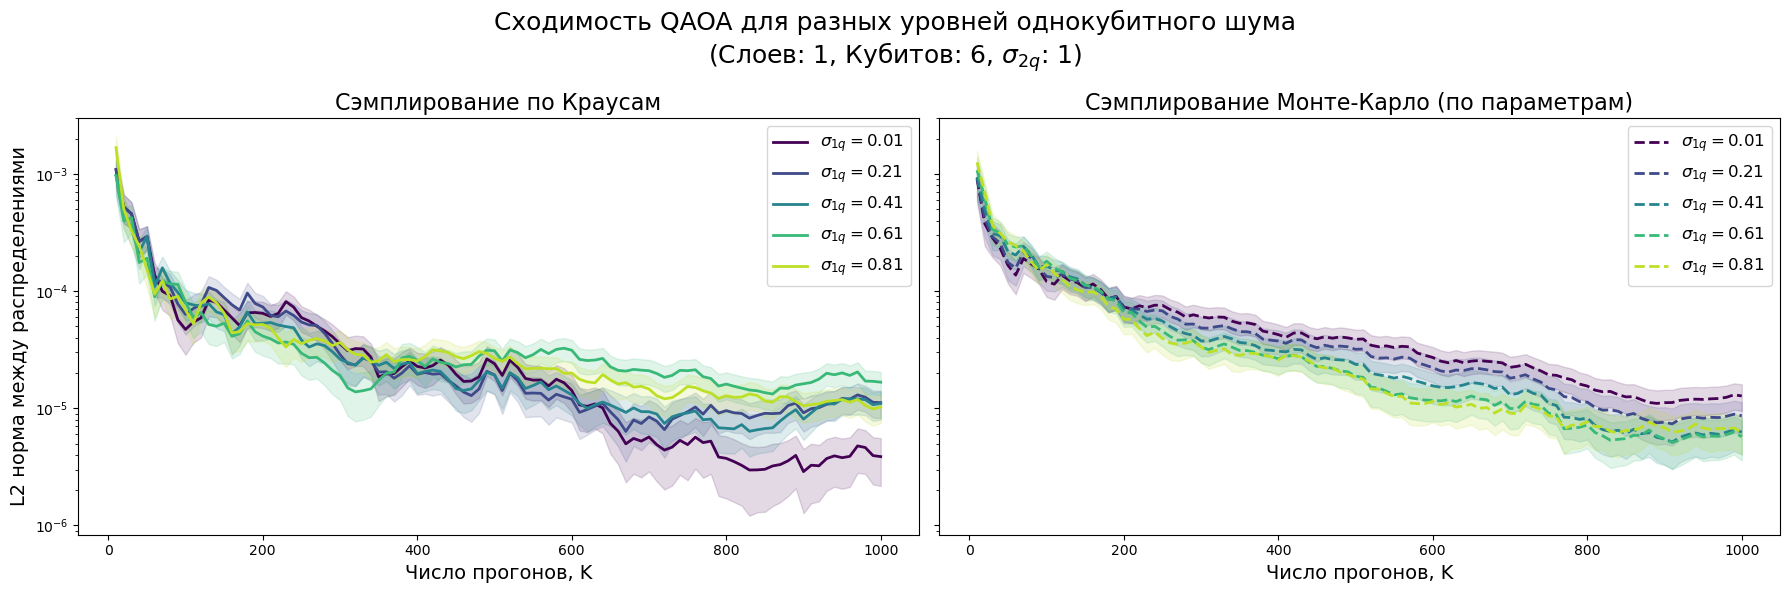

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# Получаем палитру, чтобы разные sigma были разного цвета
colors = plt.cm.viridis(np.linspace(0, 0.9, len(sigmas_1q)))

for idx, sig_1q in enumerate(sigmas_1q):
    color = colors[idx]
    label_str = rf'$\sigma_{{1q}} = {np.round(sig_1q, 3)}$'
    
    # График 1: Краус-сэмплинг
    y_kr = results_kraus[sig_1q]
    err_kr = errors_kraus[sig_1q]
    ax1.plot(K, y_kr, label=label_str, color=color, linewidth=2)
    
    ax1.fill_between(K, y_kr - err_kr, y_kr + err_kr, color=color, alpha=0.15)
    
    y_mc = results_mc[sig_1q]
    err_mc = errors_mc[sig_1q]
    ax2.plot(K, y_mc, label=label_str, color=color, linewidth=2, linestyle='--')
    ax2.fill_between(K, y_mc - err_mc, y_mc + err_mc, color=color, alpha=0.15)

# Настройка левого графика (Краус)
ax1.set_title('Сэмплирование по Краусам', fontsize=16)
ax1.set_xlabel('Число прогонов, K', fontsize=14)
ax1.set_ylabel('L2 норма между распределениями', fontsize=14)
ax1.set_yscale('log')
ax1.legend(fontsize=12)

# Настройка правого графика (Монте-Карло)
ax2.set_title('Сэмплирование Монте-Карло (по параметрам)', fontsize=16)
ax2.set_xlabel('Число прогонов, K', fontsize=14)
ax2.legend(fontsize=12)

plt.suptitle(f'Сходимость QAOA для разных уровней однокубитного шума\n(Слоев: {p}, Кубитов: {num_qubits}, $\sigma_{{2q}}$: {sigma_2q})', fontsize=18)
plt.tight_layout()
plt.show()

In [47]:
sigma_1q = 1
sigmas_2q = np.arange(0.01, 1.01, 0.2)

In [48]:
K = np.arange(10, 1010, 10)

# Словари для накопления данных
results_kraus = {}
results_mc = {}
errors_kraus = {}
errors_mc = {}

# Запуск симуляций
for sig_2q in sigmas_2q:
    dist_kraus_exact = []
    dist_monte_carlo_exact = []
    dist_kraus_exact_err = []
    dist_monte_carlo_exact_err = []

    # Точное распределение для текущих параметров шума
    exact = exact_probs(num_qubits=num_qubits, p=p, 
                        sigma_1q=sig_1q, sigma_2q=sigma_2q, seed=seed)
    
    for num_of_simulations in K:
        kraus_probs, kraus_err = kraus_samples_probs(
            num_qubits=num_qubits, p=p, num_samples=num_of_simulations, 
            sigma_1q=sig_1q, sigma_2q=sigma_2q, seed=seed
        )
        monte_probs, monte_err = monte_carlo_probs(
            num_qubits=num_qubits, p=p, num_samples=num_of_simulations, 
            sigma_1q=sig_1q, sigma_2q=sigma_2q, seed=seed
        )
        
        # Расчет расстояний (предполагается, что dist возвращает L2 норму и ошибку)
        dist_kr_res = dist(exact, kraus_probs, kraus_err)
        dist_mc_res = dist(exact, monte_probs, monte_err)

        dist_kraus_exact.append(dist_kr_res[0])
        dist_monte_carlo_exact.append(dist_mc_res[0])
        dist_kraus_exact_err.append(dist_kr_res[1])
        dist_monte_carlo_exact_err.append(dist_mc_res[1])

    # Сохраняем в словари как numpy массивы
    results_kraus[sig_2q] = np.array(dist_kraus_exact)
    results_mc[sig_2q] = np.array(dist_monte_carlo_exact)
    errors_kraus[sig_2q] = np.array(dist_kraus_exact_err)
    errors_mc[sig_2q] = np.array(dist_monte_carlo_exact_err)

<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\s'
/var/folders/86/5xcctjn15052xcf5hwdbv_6h0000gp/T/ipykernel_39343/769924082.py:34: SyntaxWarning: invalid escape sequence '\s'
  plt.suptitle(f'Сходимость QAOA для разных уровней двухкубитного шума\n(Слоев: {p}, Кубитов: {num_qubits}, $\sigma_{{1q}}$: {sigma_1q})', fontsize=18)


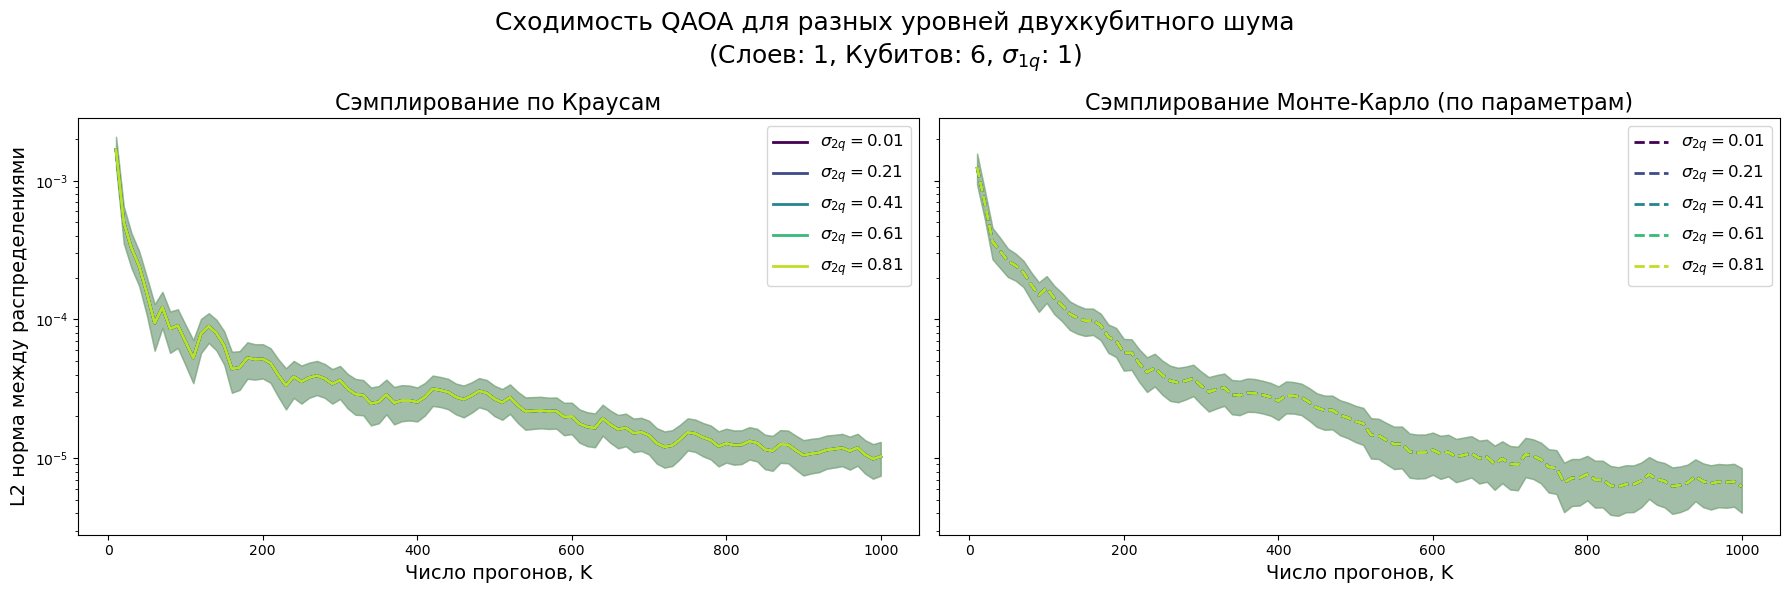

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# Получаем палитру, чтобы разные sigma были разного цвета
colors = plt.cm.viridis(np.linspace(0, 0.9, len(sigmas_2q)))

for idx, sig_2q in enumerate(sigmas_2q):
    color = colors[idx]
    label_str = rf'$\sigma_{{2q}} = {np.round(sig_2q,3)}$'
    
    # График 1: Краус-сэмплинг
    y_kr = results_kraus[sig_2q]
    err_kr = errors_kraus[sig_2q]
    ax1.plot(K, y_kr, label=label_str, color=color, linewidth=2)
    
    ax1.fill_between(K, y_kr - err_kr, y_kr + err_kr, color=color, alpha=0.15)
    
    y_mc = results_mc[sig_2q]
    err_mc = errors_mc[sig_2q]
    ax2.plot(K, y_mc, label=label_str, color=color, linewidth=2, linestyle='--')
    ax2.fill_between(K, y_mc - err_mc, y_mc + err_mc, color=color, alpha=0.15)

# Настройка левого графика (Краус)
ax1.set_title('Сэмплирование по Краусам', fontsize=16)
ax1.set_xlabel('Число прогонов, K', fontsize=14)
ax1.set_ylabel('L2 норма между распределениями', fontsize=14)
ax1.set_yscale('log')
ax1.legend(fontsize=12)

# Настройка правого графика (Монте-Карло)
ax2.set_title('Сэмплирование Монте-Карло (по параметрам)', fontsize=16)
ax2.set_xlabel('Число прогонов, K', fontsize=14)
ax2.legend(fontsize=12)

plt.suptitle(f'Сходимость QAOA для разных уровней двухкубитного шума\n(Слоев: {p}, Кубитов: {num_qubits}, $\sigma_{{1q}}$: {sigma_1q})', fontsize=18)
plt.tight_layout()
plt.show()